预测

In [1]:
from pathlib import Path
import sys

import pandas as pd

# Ensure project root is on sys.path
PROJECT_ROOT = Path('/home/hmx42/Projects/Kronos_projest')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from model import Kronos, KronosTokenizer, KronosPredictor

# Model and predictor
tokenizer = KronosTokenizer.from_pretrained('NeoQuasar/Kronos-Tokenizer-base')
model = Kronos.from_pretrained('NeoQuasar/Kronos-small')
predictor = KronosPredictor(model, tokenizer, device=None, max_context=512)

lookback = 400
pred_len = 120
batch_size = 4
target_count = 100

# Local data source
local_data_path = PROJECT_ROOT / 'data' / 'processed_datasets' / 'all_stocks_data.csv'
if not local_data_path.exists():
    raise FileNotFoundError(f'找不到本地数据文件: {local_data_path}')

print(f'读取本地数据: {local_data_path}')
all_data = pd.read_csv(local_data_path)

required_columns = ['ts_code', 'timestamps', 'open', 'high', 'low', 'close', 'volume', 'amount']
missing_columns = [col for col in required_columns if col not in all_data.columns]
if missing_columns:
    raise RuntimeError(f'本地数据缺少必要列: {missing_columns}')

all_data['timestamps'] = pd.to_datetime(all_data['timestamps'])
all_data = all_data.sort_values(['ts_code', 'timestamps']).reset_index(drop=True)

# Keep only stocks with enough history for lookback + pred_len
needed = lookback + pred_len
stock_counts = all_data.groupby('ts_code').size().sort_index()
eligible_codes = stock_counts[stock_counts >= needed].index.tolist()
eligible_codes = eligible_codes[:target_count]
print(f'可用于预测的股票数量: {len(eligible_codes)}，准备按 {batch_size} 只/批 预测')

data_dir = PROJECT_ROOT / 'data' / 'processed_datasets' / 'batch_predictions'
data_dir.mkdir(parents=True, exist_ok=True)

batch_results = []
failed_stocks = []
prepared = []

def prepare_stock_data(ts_code):
    df = all_data[all_data['ts_code'] == ts_code].copy()
    if df.empty:
        return None, None, None
    df = df.sort_values('timestamps').reset_index(drop=True)
    if len(df) < needed:
        return None, None, None
    df = df.iloc[-needed:].reset_index(drop=True)
    x_df = df.loc[:lookback-1, ['open', 'high', 'low', 'close', 'volume', 'amount']]
    x_timestamp = df.loc[:lookback-1, 'timestamps']
    y_timestamp = df.loc[lookback:lookback+pred_len-1, 'timestamps']
    return x_df, x_timestamp, y_timestamp

print('开始准备前 100 只股票的数据...')
for ts_code in eligible_codes:
    try:
        x_df, x_timestamp, y_timestamp = prepare_stock_data(ts_code)
        if x_df is None:
            failed_stocks.append(ts_code)
            continue
        prepared.append((ts_code, x_df, x_timestamp, y_timestamp))
    except Exception as e:
        print(f'准备失败 {ts_code}: {e}')
        failed_stocks.append(ts_code)

print(f'成功准备 {len(prepared)} 只股票，失败 {len(failed_stocks)} 只')

for start_idx in range(0, len(prepared), batch_size):
    batch = prepared[start_idx:start_idx + batch_size]
    ts_codes = [item[0] for item in batch]
    df_list = [item[1] for item in batch]
    x_timestamp_list = [item[2] for item in batch]
    y_timestamp_list = [item[3] for item in batch]

    print(f'预测批次 {start_idx // batch_size + 1}: {ts_codes}')
    pred_df_list = predictor.predict_batch(
        df_list=df_list,
        x_timestamp_list=x_timestamp_list,
        y_timestamp_list=y_timestamp_list,
        pred_len=pred_len,
        T=1.0,
        top_p=0.9,
        sample_count=1,
        verbose=False
    )

    for ts_code, pred_df in zip(ts_codes, pred_df_list):
        pred_df = pred_df.copy()
        pred_df.insert(0, 'ts_code', ts_code)
        batch_results.append(pred_df)

        out_path = data_dir / f'{ts_code.replace(".", "_")}_prediction.csv'
        pred_df.to_csv(out_path, index=False)

print(f'\n完成预测: {len(batch_results)} 只股票')
if batch_results:
    all_pred_df = pd.concat(batch_results, ignore_index=True)
    summary_path = data_dir / 'all_predictions_100_stocks.csv'
    all_pred_df.to_csv(summary_path, index=False)
    print(f'汇总文件已保存: {summary_path}')
print(f'失败股票数: {len(failed_stocks)}')
if failed_stocks:
    print('失败股票示例:', failed_stocks[:10])

读取本地数据: /home/hmx42/Projects/Kronos_projest/data/processed_datasets/all_stocks_data.csv
可用于预测的股票数量: 100，准备按 4 只/批 预测
开始准备前 100 只股票的数据...
成功准备 100 只股票，失败 0 只
预测批次 1: ['000001.SZ', '000002.SZ', '000006.SZ', '000007.SZ']
预测批次 2: ['000008.SZ', '000009.SZ', '000011.SZ', '000012.SZ']
预测批次 3: ['000014.SZ', '000017.SZ', '000019.SZ', '000020.SZ']
预测批次 4: ['000021.SZ', '000025.SZ', '000026.SZ', '000027.SZ']
预测批次 5: ['000028.SZ', '000029.SZ', '000030.SZ', '000031.SZ']
预测批次 6: ['000032.SZ', '000034.SZ', '000035.SZ', '000036.SZ']
预测批次 7: ['000037.SZ', '000039.SZ', '000042.SZ', '000045.SZ']
预测批次 8: ['000048.SZ', '000049.SZ', '000050.SZ', '000055.SZ']
预测批次 9: ['000058.SZ', '000059.SZ', '000060.SZ', '000061.SZ']
预测批次 10: ['000062.SZ', '000063.SZ', '000065.SZ', '000066.SZ']
预测批次 11: ['000068.SZ', '000069.SZ', '000070.SZ', '000088.SZ']
预测批次 12: ['000089.SZ', '000090.SZ', '000096.SZ', '000099.SZ']
预测批次 13: ['000100.SZ', '000151.SZ', '000153.SZ', '000155.SZ']
预测批次 14: ['000156.SZ', '000157.SZ', '000158.SZ

策略

In [2]:
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Strategy parameters
holding_count = 10
lookback_window = 20
rebalance_freq = 'daily'

print(f"交易策略配置: 持有{holding_count}只, 每日调仓, 等权重")
print(f"历史回撤窗口: {lookback_window}日\n")

# Reconstruct time series for each stock
stock_signals = []

for ts_code in eligible_codes:
    # Historical data
    hist_data = all_data[all_data['ts_code'] == ts_code].copy()
    hist_data = hist_data.sort_values('timestamps').reset_index(drop=True)
    
    if len(hist_data) < lookback_window:
        continue
    
    # Prediction data
    pred_data = all_pred_df[all_pred_df['ts_code'] == ts_code].copy()
    if pred_data.empty:
        continue
    
    pred_data['timestamps'] = pd.to_datetime(pred_data.index)
    
    # Calculate historical volatility (last lookback_window days)
    hist_returns = hist_data['close'].pct_change().tail(lookback_window)
    hist_volatility = hist_returns.std()
    if hist_volatility == 0:
        hist_volatility = 0.001  # Avoid division by zero
    
    # Calculate predicted returns (next pred_len days)
    pred_close_start = pred_data['close'].iloc[0] if len(pred_data) > 0 else hist_data['close'].iloc[-1]
    pred_close_end = pred_data['close'].iloc[-1] if len(pred_data) > 0 else pred_close_start
    pred_return = (pred_close_end - pred_close_start) / pred_close_start if pred_close_start != 0 else 0
    
    # Calculate predicted volatility (from predicted close prices)
    if len(pred_data) > 1:
        pred_returns = pred_data['close'].pct_change().dropna()
        pred_volatility = pred_returns.std()
    else:
        pred_volatility = 0.001
    
    if pred_volatility == 0:
        pred_volatility = 0.001
    
    # Reward-to-Drawdown Ratio (using predicted return / predicted volatility as proxy for Sharpe)
    reward_drawdown_ratio = pred_return / pred_volatility
    
    # Store signal
    last_hist_date = hist_data['timestamps'].iloc[-1]
    first_pred_date = pred_data.index[0] if len(pred_data) > 0 else last_hist_date
    
    stock_signals.append({
        'ts_code': ts_code,
        'date': last_hist_date,
        'pred_return': pred_return,
        'hist_volatility': hist_volatility,
        'pred_volatility': pred_volatility,
        'reward_drawdown_ratio': reward_drawdown_ratio,
        'last_close': hist_data['close'].iloc[-1]
    })

signals_df = pd.DataFrame(stock_signals)
signals_df = signals_df.sort_values('reward_drawdown_ratio', ascending=False).reset_index(drop=True)

print(f"所有 {len(signals_df)} 只股票的信号计算完成\n")
print("Top 10 排序结果:")
print(signals_df[['ts_code', 'reward_drawdown_ratio', 'pred_return', 'hist_volatility']].head(10).to_string())

# Daily trading signals
top_10_codes = signals_df.head(holding_count)['ts_code'].tolist()

# Generate trading signals
trading_signals = {
    'date': signals_df['date'].iloc[0] if len(signals_df) > 0 else pd.Timestamp.today(),
    'buy_signals': [],
    'sell_signals': [],
    'holding': top_10_codes
}

# For the first trading day, all top 10 are buy signals
for i, row in signals_df.head(holding_count).iterrows():
    trading_signals['buy_signals'].append({
        'ts_code': row['ts_code'],
        'ratio': row['reward_drawdown_ratio'],
        'weight': 1.0 / holding_count,
        'action': 'BUY',
        'trigger': '首次纳入'
    })

print(f"\n\n=== 日期: {trading_signals['date'].strftime('%Y-%m-%d')} ===")
print(f"\n【买入信号】({len(trading_signals['buy_signals'])}只):")
for sig in trading_signals['buy_signals']:
    print(f"  {sig['ts_code']}: 比率={sig['ratio']:.4f}, 权重={sig['weight']:.1%}")

print(f"\n【持仓清单】({holding_count}只):")
for code in top_10_codes:
    print(f"  {code}")

# Save trading signals to file
output_dir = PROJECT_ROOT / 'data' / 'processed_datasets' / 'trading_signals'
output_dir.mkdir(parents=True, exist_ok=True)

# Save daily signals
signals_df_out = signals_df[['ts_code', 'reward_drawdown_ratio', 'pred_return', 'hist_volatility', 'last_close']].copy()
signals_df_out['date'] = signals_df['date'].iloc[0] if len(signals_df) > 0 else pd.Timestamp.today()
signals_df_out.to_csv(output_dir / 'daily_ranking.csv', index=False)

# Save top 10
top_10_df = signals_df.head(holding_count)[['ts_code', 'reward_drawdown_ratio', 'pred_return', 'hist_volatility']].copy()
top_10_df['weight'] = 1.0 / holding_count
top_10_df['action'] = 'HOLD'
top_10_df.to_csv(output_dir / 'today_portfolio.csv', index=False)

print(f"\n\n文件已保存到: {output_dir}")
print(f"  - daily_ranking.csv (所有股票排序)")
print(f"  - today_portfolio.csv (今日持仓清单)")


交易策略配置: 持有10只, 每日调仓, 等权重
历史回撤窗口: 20日

所有 100 只股票的信号计算完成

Top 10 排序结果:
     ts_code  reward_drawdown_ratio  pred_return  hist_volatility
0  000402.SZ              14.512180     0.392380         0.046268
1  000158.SZ              14.102996     0.754770         0.022112
2  000096.SZ              12.421432     0.259889         0.010962
3  000503.SZ              11.782802     0.435997         0.019849
4  000403.SZ              10.674482     0.224948         0.012880
5  000526.SZ               9.719053     0.183169         0.026571
6  000521.SZ               8.817518     0.119519         0.009789
7  000002.SZ               4.907106     0.082157         0.016708
8  000028.SZ               3.611550     0.046864         0.011814
9  000419.SZ               3.352354     0.100458         0.015093


=== 日期: 2026-05-15 ===

【买入信号】(10只):
  000402.SZ: 比率=14.5122, 权重=10.0%
  000158.SZ: 比率=14.1030, 权重=10.0%
  000096.SZ: 比率=12.4214, 权重=10.0%
  000503.SZ: 比率=11.7828, 权重=10.0%
  000403.SZ: 比率=10.6745, 权重=1

In [5]:
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ============ 每日调仓清单生成 ============
print("\n" + "="*60)
print("每日调仓清单生成 (基于预测数据)")
print("="*60 + "\n")

holding_count = 10
test_days = min(120, len(all_pred_df) // 100)  # 预测数据共 100 * 120 = 12000 行，每只 120 行

print(f"回测天数: {test_days}")
print(f"持仓数量: {holding_count}\n")

# 存储每日调仓信息
daily_rebalance = []
prev_holdings = set()

# 遍历每一天
for day in range(test_days):
    # 计算当前日期的排序信号
    signals_list = []
    
    for ts_code in eligible_codes:
        pred_data = all_pred_df[all_pred_df['ts_code'] == ts_code].copy()
        
        if pred_data.empty:
            continue
        
        # 重置索引以便按行号访问
        pred_data = pred_data.reset_index(drop=True)
        
        if len(pred_data) <= day:
            continue
        
        # 当前价格（该行的收盘价）
        current_price = pred_data.loc[day, 'close']
        
        # 从当前日期到末尾的预测数据
        remaining_pred = pred_data.iloc[day:].copy()
        
        if len(remaining_pred) < 2:
            continue
        
        # 计算剩余期间的收益率
        pred_start = remaining_pred['close'].iloc[0]
        pred_end = remaining_pred['close'].iloc[-1]
        pred_return = (pred_end - pred_start) / pred_start if pred_start > 0 else 0
        
        # 计算波动率
        pred_returns = remaining_pred['close'].pct_change().dropna()
        pred_volatility = max(pred_returns.std(), 0.001)
        
        # 收益/波动率 信号
        signal_ratio = pred_return / pred_volatility if pred_volatility > 0 else 0
        
        signals_list.append({
            'ts_code': ts_code,
            'signal_ratio': signal_ratio,
            'current_price': current_price,
            'pred_return': pred_return,
            'pred_volatility': pred_volatility
        })
    
    # 排序取前 10
    signals_df = pd.DataFrame(signals_list)
    if len(signals_df) > 0:
        signals_df = signals_df.sort_values('signal_ratio', ascending=False)
        top_10_today = signals_df.head(holding_count)['ts_code'].tolist()
    else:
        top_10_today = []
    
    # 计算买卖信号
    current_holdings = set(top_10_today)
    to_buy = current_holdings - prev_holdings
    to_sell = prev_holdings - current_holdings
    to_hold = prev_holdings & current_holdings
    
    # 记录调仓
    daily_rebalance.append({
        'day': day + 1,
        'buy_count': len(to_buy),
        'sell_count': len(to_sell),
        'hold_count': len(to_hold),
        'holdings_count': len(current_holdings),
        'top_10': ','.join(top_10_today)
    })
    
    if (day + 1) % 30 == 0 or day == 0 or day == test_days - 1:
        print(f"Day {day+1:3d}: 买入{len(to_buy):>2d} | 卖出{len(to_sell):>2d} | 持仓{len(to_hold):>2d} | 总持仓{len(current_holdings):>2d}")
    
    prev_holdings = current_holdings

# 保存每日调仓清单
rebalance_dir = PROJECT_ROOT / 'data' / 'trading_signals' / 'daily_rebalance'
rebalance_dir.mkdir(parents=True, exist_ok=True)

rebalance_df = pd.DataFrame(daily_rebalance)
rebalance_df.to_csv(rebalance_dir / 'daily_rebalance_120d.csv', index=False)

print(f"\n✓ 每日调仓清单已保存: {rebalance_dir / 'daily_rebalance_120d.csv'}")
print(f"  共 {len(rebalance_df)} 个交易日")
print(f"\n调仓统计:")
print(f"  平均每日买入: {rebalance_df['buy_count'].mean():.2f} 只")
print(f"  平均每日卖出: {rebalance_df['sell_count'].mean():.2f} 只")
print(f"\n样本数据:")
print(rebalance_df.head(10).to_string())



每日调仓清单生成 (基于预测数据)

回测天数: 120
持仓数量: 10

Day   1: 买入10 | 卖出 0 | 持仓 0 | 总持仓10
Day  30: 买入 1 | 卖出 1 | 持仓 9 | 总持仓10
Day  60: 买入 1 | 卖出 1 | 持仓 9 | 总持仓10
Day  90: 买入 2 | 卖出 2 | 持仓 8 | 总持仓10
Day 120: 买入 0 | 卖出10 | 持仓 0 | 总持仓 0

✓ 每日调仓清单已保存: /home/hmx42/Projects/Kronos_projest/data/trading_signals/daily_rebalance/daily_rebalance_120d.csv
  共 120 个交易日

调仓统计:
  平均每日买入: 1.56 只
  平均每日卖出: 1.56 只

样本数据:
   day  buy_count  sell_count  hold_count  holdings_count                                                                                               top_10
0    1         10           0           0              10  000402.SZ,000158.SZ,000096.SZ,000503.SZ,000403.SZ,000526.SZ,000521.SZ,000002.SZ,000028.SZ,000419.SZ
1    2          0           0          10              10  000402.SZ,000096.SZ,000158.SZ,000503.SZ,000403.SZ,000521.SZ,000526.SZ,000002.SZ,000419.SZ,000028.SZ
2    3          1           1           9              10  000402.SZ,000158.SZ,000096.SZ,000503.SZ,000403.SZ,000521.SZ,000526.SZ,0

✓ 图表已保存: /home/hmx42/Projects/Kronos_projest/figures/backtest_comparison_120d.png

119天投资组合性能对比

最终资产净值:
  预测:        1,401,156 CNY (+  40.12%)
  真实:          647,628 CNY (+ -35.24%)
  差异:          753,528 CNY ( 116.35%)

最大回撤:
  预测:     8.10%
  真实:    35.24%

年化收益率（外推）:
  预测:    84.95%
  真实:   -74.62%



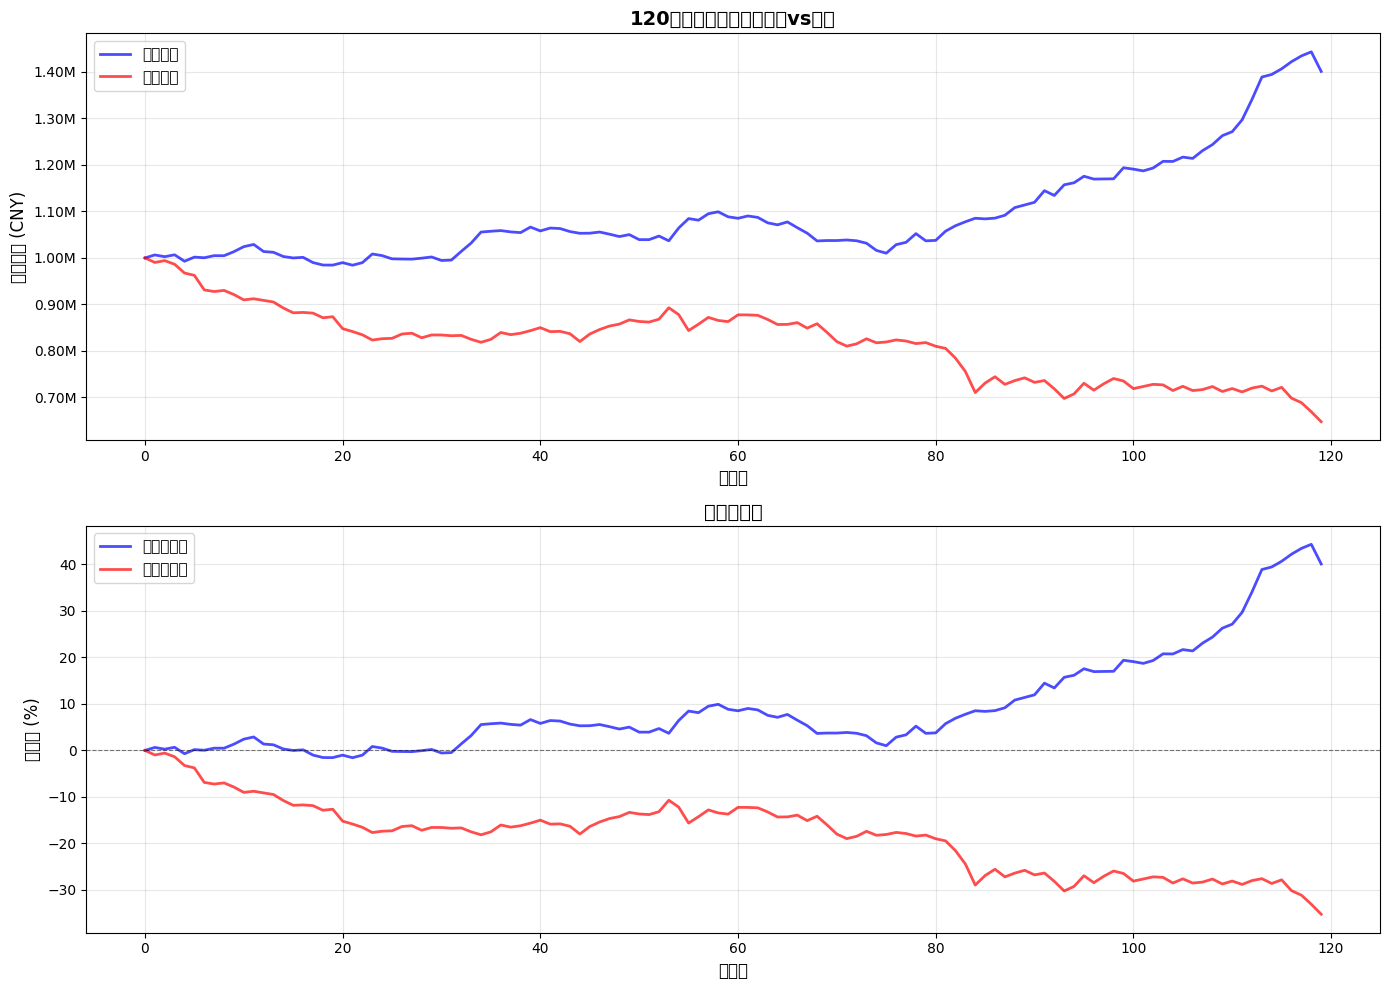

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# 读取调仓清单
rebalance_csv_path = rebalance_dir / 'daily_rebalance_120d.csv'
rebalance_df = pd.read_csv(rebalance_csv_path)

# 移除最后一行（第120天没有top_10数据）
rebalance_df = rebalance_df.dropna(subset=['top_10'])
test_days_actual = len(rebalance_df)

# 初始化收益追踪
initial_capital = 1000000  # 100万
fee_rate = 0.001  # 0.1%交易费

pred_equity = [initial_capital]  # 预测收益曲线
real_equity = [initial_capital]  # 真实收益曲线

# 计算每一天的收益
for day in range(test_days_actual):
    top_10_str = rebalance_df.iloc[day]['top_10']
    top_10_codes = [code.strip() for code in top_10_str.split(',')]
    weight_per_stock = 1.0 / 10  # 等权重
    
    # ==================== 预测收益 ====================
    day_pred_return = 0
    for ts_code in top_10_codes:
        pred_data = all_pred_df[all_pred_df['ts_code'] == ts_code].reset_index(drop=True)
        if len(pred_data) <= day:
            continue
        # 预测：从当前day到day+1的价格变化
        if day < len(pred_data) - 1:
            day_open = pred_data.iloc[day]['close']
            day_close = pred_data.iloc[day + 1]['close']
            daily_return = (day_close - day_open) / day_open
        else:
            daily_return = 0
        day_pred_return += daily_return * weight_per_stock
    
    # 加上交易费（假设每天都调仓一次）
    buy_count = rebalance_df.iloc[day]['buy_count']
    sell_count = rebalance_df.iloc[day]['sell_count']
    trade_cost = (buy_count + sell_count) * fee_rate
    day_pred_return -= trade_cost
    
    pred_equity.append(pred_equity[-1] * (1 + day_pred_return))
    
    # ==================== 真实收益 ====================
    day_real_return = 0
    for ts_code in top_10_codes:
        # 获取真实数据
        real_data = all_data[all_data['ts_code'] == ts_code].sort_values('timestamps').reset_index(drop=True)
        if len(real_data) <= lookback + day:
            continue
        # 真实数据：从lookback+day到lookback+day+1的价格变化
        day_open = real_data.iloc[lookback + day]['close']
        day_close = real_data.iloc[lookback + day + 1]['close']
        daily_return = (day_close - day_open) / day_open
        day_real_return += daily_return * weight_per_stock
    
    # 加上交易费
    day_real_return -= trade_cost
    
    real_equity.append(real_equity[-1] * (1 + day_real_return))

# 生成图表
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 图1：绝对收益曲线
ax1 = axes[0]
days_array = np.arange(len(pred_equity))
ax1.plot(days_array, pred_equity, label='预测收益', linewidth=2, color='blue', alpha=0.7)
ax1.plot(days_array, real_equity, label='真实收益', linewidth=2, color='red', alpha=0.7)
ax1.set_xlabel('交易日', fontsize=12)
ax1.set_ylabel('资产净值 (CNY)', fontsize=12)
ax1.set_title('120天投资组合对比：预测vs真实', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.2f}M'))

# 图2：收益率曲线
pred_returns = np.array(pred_equity) / initial_capital
real_returns = np.array(real_equity) / initial_capital
ax2 = axes[1]
ax2.plot(days_array, (pred_returns - 1) * 100, label='预测收益率', linewidth=2, color='blue', alpha=0.7)
ax2.plot(days_array, (real_returns - 1) * 100, label='真实收益率', linewidth=2, color='red', alpha=0.7)
ax2.set_xlabel('交易日', fontsize=12)
ax2.set_ylabel('收益率 (%)', fontsize=12)
ax2.set_title('收益率对比', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
output_path = PROJECT_ROOT / 'figures' / 'backtest_comparison_120d.png'
output_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_path, dpi=150, bbox_inches='tight')
print(f"✓ 图表已保存: {output_path}")

# 输出性能指标
print("\n" + "="*60)
print(f"{test_days_actual}天投资组合性能对比")
print("="*60)

pred_final_return = (pred_equity[-1] - initial_capital) / initial_capital * 100
real_final_return = (real_equity[-1] - initial_capital) / initial_capital * 100

print(f"\n最终资产净值:")
print(f"  预测:  {pred_equity[-1]:>15,.0f} CNY (+{pred_final_return:>7.2f}%)")
print(f"  真实:  {real_equity[-1]:>15,.0f} CNY (+{real_final_return:>7.2f}%)")
print(f"  差异:  {pred_equity[-1] - real_equity[-1]:>15,.0f} CNY ({(pred_equity[-1]/real_equity[-1] - 1)*100:>7.2f}%)")

# 计算最大回撤
def max_drawdown(equity_curve):
    peak = equity_curve[0]
    max_dd = 0
    for val in equity_curve:
        if val > peak:
            peak = val
        dd = (peak - val) / peak
        max_dd = max(max_dd, dd)
    return max_dd * 100

print(f"\n最大回撤:")
print(f"  预测:  {max_drawdown(pred_equity):>7.2f}%")
print(f"  真实:  {max_drawdown(real_equity):>7.2f}%")

# 计算年化收益率（假设252个交易日每年）
annualized_pred = (pred_final_return / test_days_actual) * 252
annualized_real = (real_final_return / test_days_actual) * 252

print(f"\n年化收益率（外推）:")
print(f"  预测:  {annualized_pred:>7.2f}%")
print(f"  真实:  {annualized_real:>7.2f}%")

print("\n" + "="*60)